In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from datetime import datetime 
from statsmodels.tsa.stattools import adfuller 
from statsmodels.tsa.arima.model import ARIMA 
from pmdarima import auto_arima 
from sklearn.metrics import mean_squared_error, mean_absolute_error 
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing 

In [3]:
df = pd.read_csv('../Dataset_NCKH/train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

In [8]:
df['Order Date']

0      2017-11-08
1      2017-11-08
2      2017-06-12
3      2016-10-11
4      2016-10-11
          ...    
9795   2017-05-21
9796   2016-01-12
9797   2016-01-12
9798   2016-01-12
9799   2016-01-12
Name: Order Date, Length: 9800, dtype: datetime64[ns]

In [10]:
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()

In [11]:
monthly_sales

Order Date
2015-01-31     14205.7070
2015-02-28      4519.8920
2015-03-31     55205.7970
2015-04-30     27906.8550
2015-05-31     23644.3030
2015-06-30     34322.9356
2015-07-31     33781.5430
2015-08-31     27117.5365
2015-09-30     81623.5268
2015-10-31     31453.3930
2015-11-30     77907.6607
2015-12-31     68167.0585
2016-01-31     18066.9576
2016-02-29     11951.4110
2016-03-31     32339.3184
2016-04-30     34154.4685
2016-05-31     29959.5305
2016-06-30     23599.3740
2016-07-31     28608.2590
2016-08-31     36818.3422
2016-09-30     63133.6060
2016-10-31     31011.7375
2016-11-30     75249.3995
2016-12-31     74543.6012
2017-01-31     18542.4910
2017-02-28     22978.8150
2017-03-31     51165.0590
2017-04-30     38679.7670
2017-05-31     56656.9080
2017-06-30     39724.4860
2017-07-31     38320.7830
2017-08-31     30542.2003
2017-09-30     69193.3909
2017-10-31     59583.0330
2017-11-30     79066.4958
2017-12-31     95739.1210
2018-01-31     43476.4740
2018-02-28     19920.9974
2

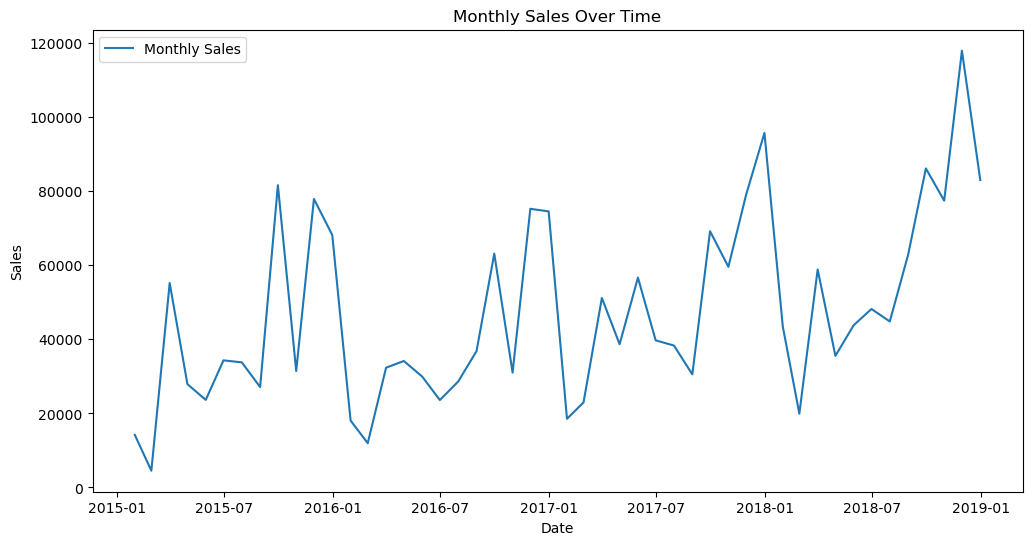

In [12]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales, label='Monthly Sales')
plt.title('Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

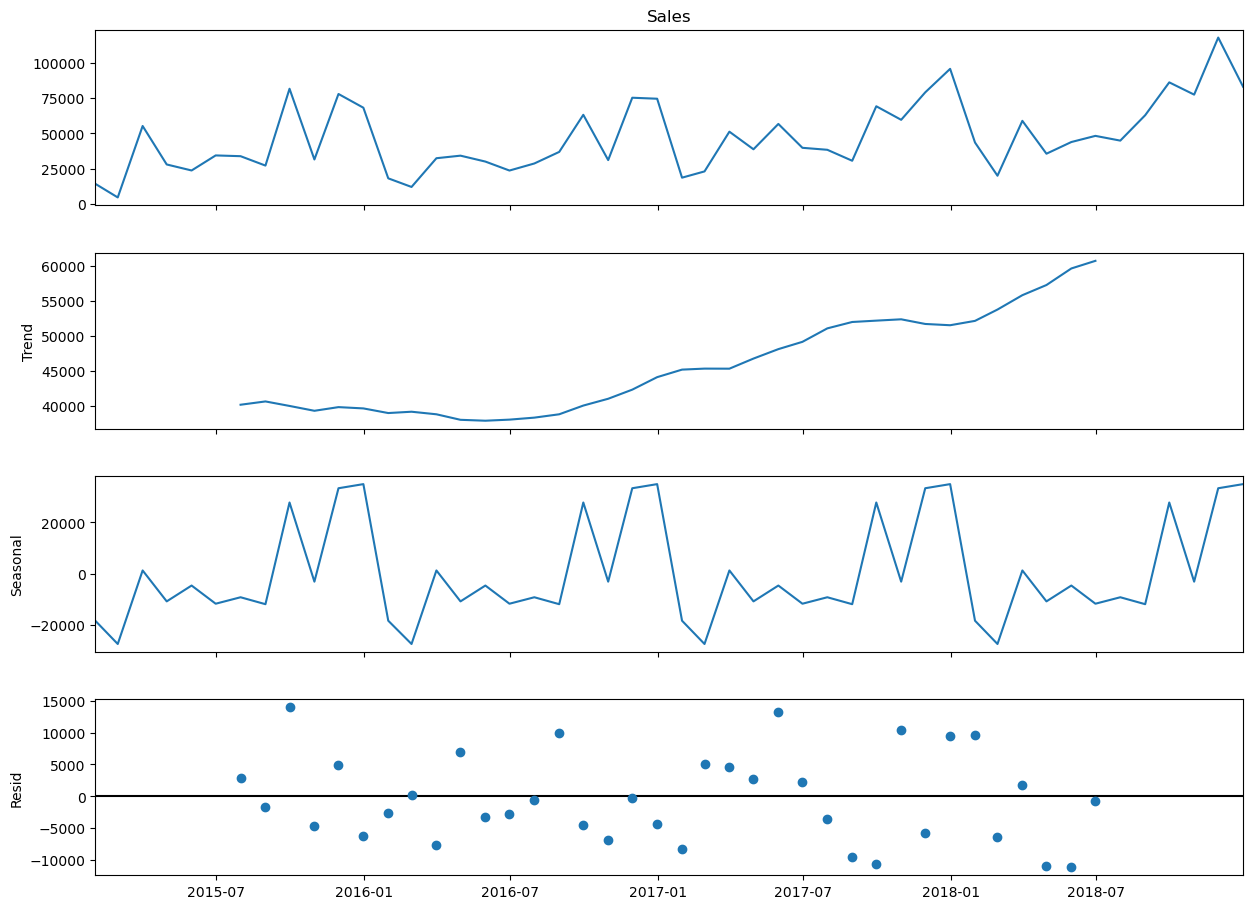

In [13]:
decomposition = seasonal_decompose(monthly_sales, model='additive')
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show() 

In [14]:
def check_stationary(timeseries): 
  result = adfuller(timeseries)
  print('Augmented Dickey-Fuller Test Result:')
  print('ADF Statistic:', result[0])
  print('p-value: ', result[1])
  print('Critical values:')
  for key, value in result[4].items():
    print(f'\t{key}: {value}')
  return result[1] < 0.05
is_stationary = check_stationary(monthly_sales)
print(f"\n Time series is {'stationary' if is_stationary else 'non-stationary'}")

Augmented Dickey-Fuller Test Result:
ADF Statistic: -4.416136761430769
p-value:  0.00027791039276670623
Critical values:
	1%: -3.5778480370438146
	5%: -2.925338105429433
	10%: -2.6007735310095064

 Time series is stationary


In [15]:
auto_model = auto_arima(monthly_sales, start_p=0, start_q=0, max_p=5, max_q=5, m=12, seasonal=True, d=None, trace=True, error_action='ignore', suppress_warnings=True, stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=1085.632, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1096.560, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1076.500, Time=0.03 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1077.487, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1094.708, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1089.579, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=1078.250, Time=0.07 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1078.452, Time=0.04 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1080.901, Time=0.03 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=1079.864, Time=0.15 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1084.035, Time=0.02 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=1073.635, Time=0.03 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1087.151, Time=0.01 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=1075.267, Time=0.09 sec
 ARIMA(2,1,0)(1,0,1

In [16]:
model = ARIMA(monthly_sales, order=auto_model.order, seasonal_order=auto_model.seasonal_order)
results = model.fit()

In [17]:
forecast_periods = 12 
forecast = results.get_forecast(steps=forecast_periods)
mean_forecast = forecast.predicted_mean 

In [18]:
mean_forecast

2019-01-31     71457.294761
2019-02-28     55170.675705
2019-03-31     75354.273337
2019-04-30     63712.967944
2019-05-31     68065.122562
2019-06-30     70562.386149
2019-07-31     68781.958301
2019-08-31     79738.551000
2019-09-30     94101.274958
2019-10-31     88767.503545
2019-11-30    113674.495426
2019-12-31     92191.072959
Freq: ME, Name: predicted_mean, dtype: float64

In [19]:
conf_int_95 = forecast.conf_int(alpha=0.05)
conf_int_80 = forecast.conf_int(alpha=0.2)
conf_int_70 = forecast.conf_int(alpha=0.3)

In [20]:
conf_int_70

,lower Sales,upper Sales
2019-01-31,47694.059972,95220.529550
2019-02-28,29621.976902,80719.374509
2019-03-31,46925.812490,103782.734184
2019-04-30,32023.997990,95401.937898
2019-05-31,34056.902993,102073.342132
2019-06-30,34159.890867,106964.881431
2019-07-31,30131.803968,107432.112634
2019-08-31,39013.214052,120463.887948
2019-09-30,51373.707351,136828.842565
2019-10-31,44133.025683,133401.981406


In [22]:
conf_int_95

,lower Sales,upper Sales
2019-01-31,26519.448476,116395.141046
2019-02-28,6856.399058,103484.952353
2019-03-31,21594.176490,129114.370184
2019-04-30,3787.033054,123638.902834
2019-05-31,3753.333488,132376.911637
2019-06-30,1722.863587,139401.908710
2019-07-31,-4308.035959,141871.952562
2019-08-31,2724.249372,156752.852628
2019-09-30,13300.622928,174901.926988
2019-10-31,4360.758293,173174.248796


In [23]:
conf_int_80

,lower Sales,upper Sales
2019-01-31,42074.016439,100840.573083
2019-02-28,23579.668236,86761.683175
2019-03-31,40202.435435,110506.111239
2019-04-30,24529.505248,102896.430640
2019-05-31,26013.903958,110116.341167
2019-06-30,25550.641747,115574.130551
2019-07-31,20990.979840,116572.936763
2019-08-31,29381.605873,130095.496127
2019-09-30,41268.568376,146933.981540
2019-10-31,33576.899343,143958.107746


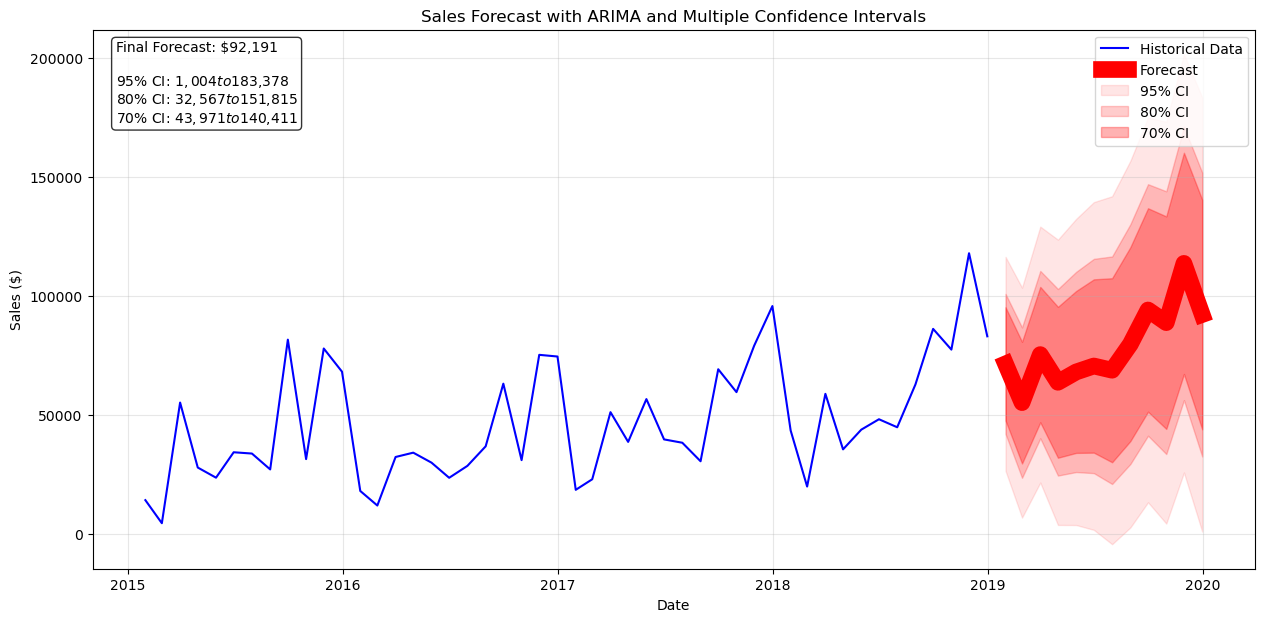

In [28]:
plt.figure(figsize=(15, 7))
plt.plot(monthly_sales, label='Historical Data', color='blue')
plt.plot(mean_forecast, label='Forecast', color='red', linewidth=12)
plt.fill_between(mean_forecast.index, conf_int_95.iloc[:,0], conf_int_95.iloc[:,1], color='red', alpha=0.1, label='95% CI') 
plt.fill_between(mean_forecast.index, conf_int_80.iloc[:,0], conf_int_80.iloc[:,1], color='red', alpha=0.2, label='80% CI')
plt.fill_between(mean_forecast.index, conf_int_70.iloc[:,0], conf_int_70.iloc[:,1], color='red', alpha=0.3, label='70% CI')
plt.title('Sales Forecast with ARIMA and Multiple Confidence Intervals')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
# Get final values 
last_forecast = mean_forecast.iloc[-1]
range_95_lower = conf_int_95.iloc[-1, 0]
range_95_upper = conf_int_95.iloc[-1, 1]
range_80_lower = conf_int_80.iloc[-1, 0]
range_80_upper = conf_int_80.iloc[-1, 1]
range_70_lower = conf_int_70.iloc[-1, 0] 
range_70_upper = conf_int_70.iloc[-1, 1]
# Create info text 
info_text = f'Final Forecast: ${last_forecast:,.0f}\n\n' + f'95% CI: ${range_95_lower:,.0f} to ${range_95_upper:,.0f}\n'+f'80% CI: ${range_80_lower:,.0f} to ${range_80_upper:,.0f}\n'+f'70% CI: ${range_70_lower:,.0f} to ${range_70_upper:,.0f}'
plt.text(0.02, 0.98, info_text, transform=plt.gca().transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.show() 

In [33]:
print("\n Model Performance Metrics:")
mse = mean_squared_error(monthly_sales, results.fittedvalues)
rmse = np.sqrt(mse)
mae = mean_absolute_error(monthly_sales, results.fittedvalues) 
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
# Print forecast informaton
print("\n Forecast Ranges for Final Period:")
print(f"Point Forecast: ${last_forecast:,.2f}")
print("\n Confidence Intervals:")
print(f"95% CI: ${range_95_lower:,.2f} to ${range_95_upper:,.2f}")
print(f"80% CI: ${range_80_lower:,.2f} to ${range_80_upper:,.2f}")
print(f"70% CI: ${range_80_lower:,.2f} to ${range_70_upper:,.2f}")

# Calculate and print interval widths 
print("\n Interval Widths as Percentage of Forecast:")
print(f"95% CI: (+ or -){((range_95_upper - range_95_lower)/2/last_forecast*100):,.1f}%")
print(f"80% CI: (+ or -){((range_80_upper - range_80_lower)/2/last_forecast*100):,.1f}%")
print(f"70% CI: (+ or -){((range_70_upper - range_70_lower)/2/last_forecast*100):,.1f}%")

#Create forecast dateframe 
forecast_df = pd.DataFrame({
  'Forecast': mean_forecast, 
  '95% Lower': conf_int_95.iloc[:,0], 
  '95% Upper': conf_int_95.iloc[:,1], 
  '80% lower': conf_int_80.iloc[:,0],
  '80% Upper': conf_int_80.iloc[:,1],
  '70% Lower': conf_int_70.iloc[:,0],
  '70% Upper': conf_int_70.iloc[:,1],
})
print('\n Detailed Forecast with confidents intervals')
print(forecast_df)


 Model Performance Metrics:
Mean Squared Error (MSE): 372198461.42
Root Mean Squared Error (RMSE): 19292.45
Mean Absolute Error (MAE): 14432.38

 Forecast Ranges for Final Period:
Point Forecast: $92,191.07

 Confidence Intervals:
95% CI: $1,003.72 to $183,378.42
80% CI: $32,566.87 to $151,815.28
70% CI: $32,566.87 to $140,411.15

 Interval Widths as Percentage of Forecast:
95% CI: (+ or -)98.9%
80% CI: (+ or -)64.7%
70% CI: (+ or -)52.3%

 Detailed Forecast with confidents intervals
                 Forecast     95% Lower  ...     70% Lower      70% Upper
2019-01-31   71457.294761  26519.448476  ...  47694.059972   95220.529550
2019-02-28   55170.675705   6856.399058  ...  29621.976902   80719.374509
2019-03-31   75354.273337  21594.176490  ...  46925.812490  103782.734184
2019-04-30   63712.967944   3787.033054  ...  32023.997990   95401.937898
2019-05-31   68065.122562   3753.333488  ...  34056.902993  102073.342132
2019-06-30   70562.386149   1722.863587  ...  34159.890867  106964

In [34]:
models = []
specifications = [
  {
    'name': 'Fixed Parameters', 
    'model': ExponentialSmoothing(
      monthly_sales, seasonal_periods=12, trend='add', seasonal='add', damped_trend=True
    ).fit(
      smoothing_level=0.2, 
      smoothing_trend=0.1, 
      smoothing_seasonal=0.1, 
      damping_trend=0.98, 
      optimized=False 
    )
  }, 
  {
    'name': 'Multiplicative Seasonal', 
    'model': ExponentialSmoothing(
      monthly_sales, 
      seasonal_periods=12, 
      trend='add', 
      seasonal='mul', 
      damped_trend=True
    ).fit(
      smoothing_level=0.2, 
      smoothing_trend=0.1, 
      smoothing_seasonal=0.1, 
      damping_trend=0.98, 
      optimized=False 
    )
  }, 
  {
    'name': 'Multiplicative Trend', 
    'model': ExponentialSmoothing(
      monthly_sales,
      seasonal_periods=12, 
      trend='mul', 
      seasonal='add', 
      damped_trend=True
    ).fit(
      smoothing_level=0.2, 
      smoothing_trend=0.1, 
      smoothing_seasonal=0.1, 
      damping_trend=0.98, 
      optimized=False 
    )
  }
]

In [35]:
specifications

[{'name': 'Fixed Parameters',
  'model': <statsmodels.tsa.holtwinters.results.HoltWintersResultsWrapper at 0x1ffc2b3d310>},
 {'name': 'Multiplicative Seasonal',
  'model': <statsmodels.tsa.holtwinters.results.HoltWintersResultsWrapper at 0x1ffc331e1b0>},
 {'name': 'Multiplicative Trend',
  'model': <statsmodels.tsa.holtwinters.results.HoltWintersResultsWrapper at 0x1ffc331d100>}]

In [37]:
results = []
for spec in specifications: 
  model = spec['model']
  name = spec['name']
  rmse = np.sqrt(mean_squared_error(monthly_sales, model.fittedvalues))
  mae = mean_absolute_error(monthly_sales, model.fittedvalues)
  results.append({
    'name': name, 
    'rmse': rmse, 
    'mae': mae, 
    'model': model
  })

In [38]:
results

[{'name': 'Fixed Parameters',
  'rmse': 9783.597250630219,
  'mae': 7831.269048033439,
  'model': <statsmodels.tsa.holtwinters.results.HoltWintersResultsWrapper at 0x1ffc2b3d310>},
 {'name': 'Multiplicative Seasonal',
  'rmse': 11758.669672436305,
  'mae': 8762.041257003448,
  'model': <statsmodels.tsa.holtwinters.results.HoltWintersResultsWrapper at 0x1ffc331e1b0>},
 {'name': 'Multiplicative Trend',
  'rmse': 9762.290924720162,
  'mae': 7841.89557727872,
  'model': <statsmodels.tsa.holtwinters.results.HoltWintersResultsWrapper at 0x1ffc331d100>}]

In [41]:
best_model = min(results, key=lambda x: x['rmse']) 
hw_model = best_model['model'] 
hw_forecast = hw_model.forecast(12)

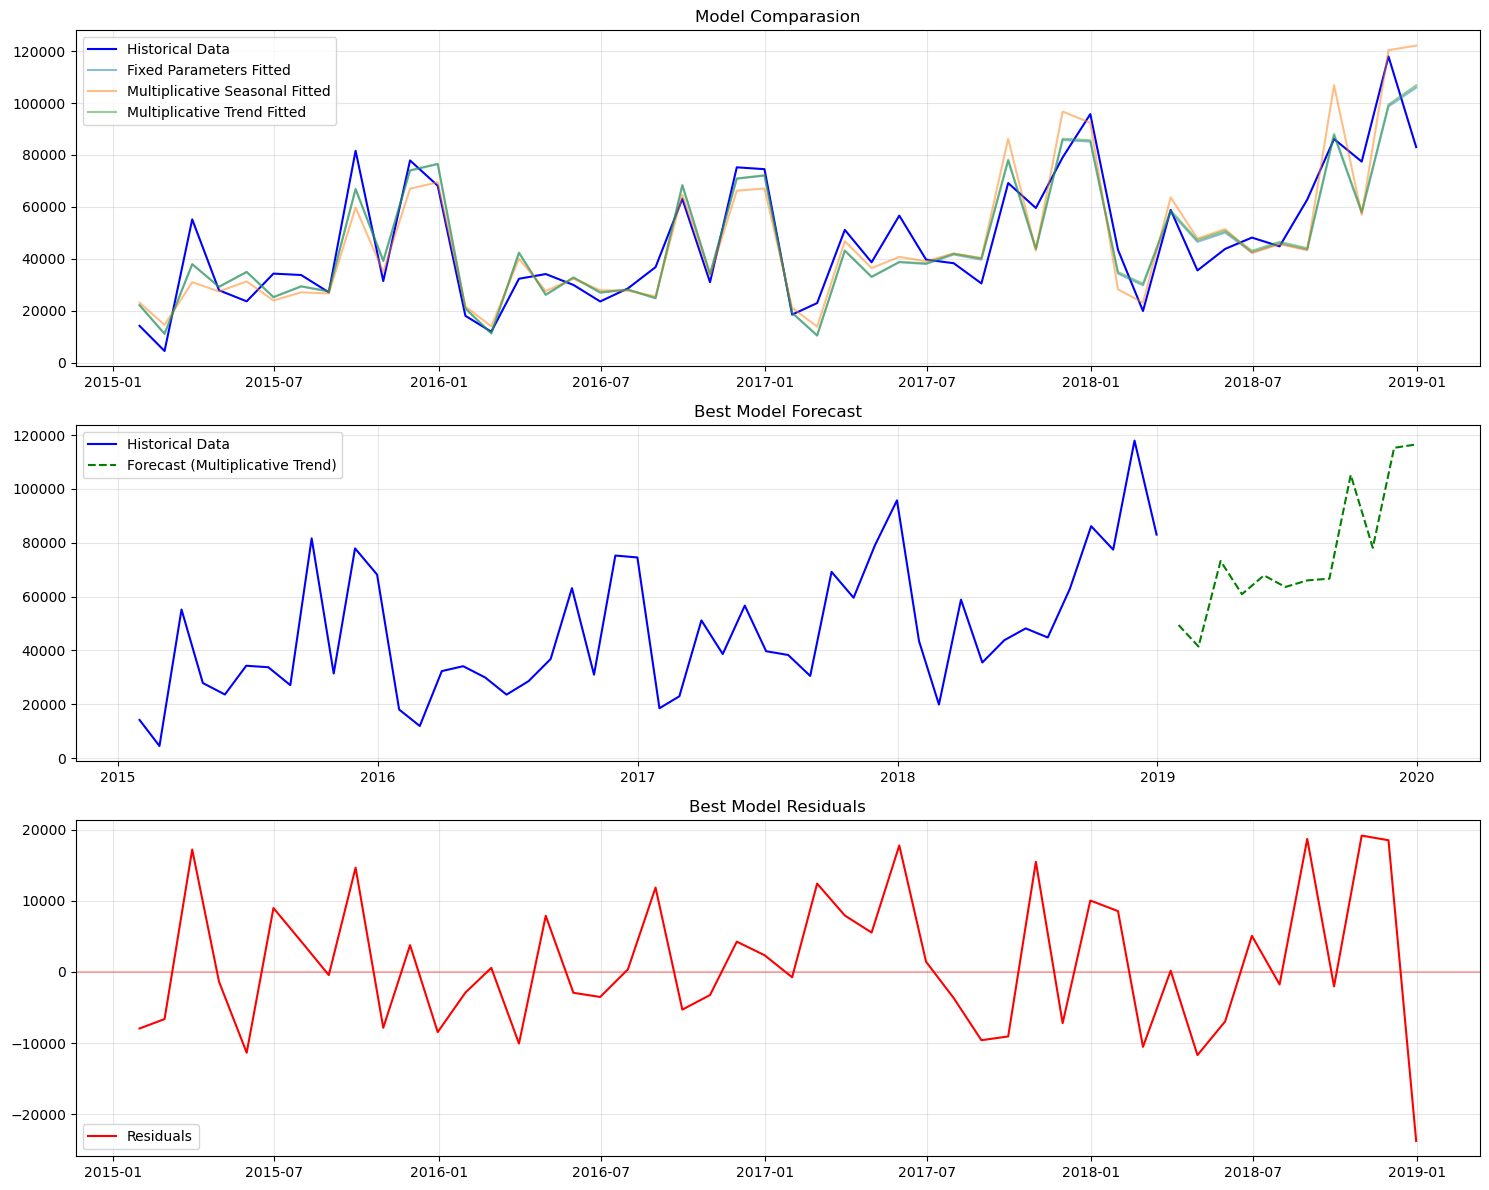

In [43]:
plt.figure(figsize=(15,12))
#First subplot: All models 
plt.subplot(3,1,1)
plt.plot(monthly_sales.index, monthly_sales, label='Historical Data', color='blue')
for result in results: 
  plt.plot(result['model'].fittedvalues.index, result['model'].fittedvalues, label=f"{result['name']} Fitted", alpha=0.5) 
plt.title('Model Comparasion')
plt.legend() 
plt.grid(True, alpha=0.3)
#Second subplot: Best model forecast 
plt.subplot(3,1,2)
plt.plot(monthly_sales.index, monthly_sales, label='Historical Data', color='blue')
plt.plot(hw_forecast.index, hw_forecast, label=f"Forecast ({best_model["name"]})", color="green", linestyle='--')
plt.title('Best Model Forecast')
plt.legend()
plt.grid(True, alpha=0.3)
#Third subplot: Residuals of best model 
plt.subplot(3,1,3)
residuals = monthly_sales - hw_model.fittedvalues 
plt.plot(monthly_sales.index, residuals, label='Residuals', color='red')
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.title('Best Model Residuals')
plt.legend()
plt.grid(True, alpha=0.3) 
plt.tight_layout()
plt.show()

In [46]:
print('\n Model Comparison:')
for result in results: 
  print(f"\n{result['name']}:")
  print(f"RMSE: ${result['rmse']:.2f}")
  print(f"MAE: ${result['mae']:.2f}")
print(f"\n Best Model: {best_model['name']}")
print(f"Best RMSE: ${best_model['rmse']:.2f}")


 Model Comparison:

Fixed Parameters:
RMSE: $9783.60
MAE: $7831.27

Multiplicative Seasonal:
RMSE: $11758.67
MAE: $8762.04

Multiplicative Trend:
RMSE: $9762.29
MAE: $7841.90

 Best Model: Multiplicative Trend
Best RMSE: $9762.29


In [47]:
print('\n Best Model Parameters:')
print(f"- Smoothing level (a): {hw_model.params['smoothing_level']:.3f}")
print(f"- Trend smoothing (B): {hw_model.params['smoothing_trend']:.3f}")
print(f"- Seasonal smoothing (y): {hw_model.params['smoothing_seasonal']:.3f}")
print(f"- Damping parameter (a): {hw_model.params['damping_trend']:.3f}")


 Best Model Parameters:
- Smoothing level (a): 0.200
- Trend smoothing (B): 0.100
- Seasonal smoothing (y): 0.100
- Damping parameter (a): 0.980


In [48]:
hw_forecast

2019-01-31     49435.711479
2019-02-28     41459.506838
2019-03-31     73220.555712
2019-04-30     60904.078997
2019-05-31     67886.536597
2019-06-30     63574.157506
2019-07-31     66020.931715
2019-08-31     66663.177848
2019-09-30    105201.488326
2019-10-31     78140.769889
2019-11-30    115255.953319
2019-12-31    116513.155267
Freq: ME, dtype: float64

In [49]:
final_results = pd.DataFrame({
  'Actual': monthly_sales, 
  'Fitted': hw_model.fittedvalues, 
  'Residuals': residuals
})

In [50]:
final_results

,Actual,Fitted,Residuals
Order Date,,,
2015-01-31,14205.7070,22155.386037,-7949.679037
2015-02-28,4519.8920,11146.811114,-6626.919114
2015-03-31,55205.7970,37975.018760,17230.778240
2015-04-30,27906.8550,29267.192066,-1360.337066
2015-05-31,23644.3030,35011.240872,-11366.937872
2015-06-30,34322.9356,25323.862069,8999.073531
2015-07-31,33781.5430,29471.746667,4309.796333
2015-08-31,27117.5365,27556.862748,-439.326248
2015-09-30,81623.5268,66942.870651,14680.656149
